# SpectraLoRA Inference Client

Predict Raman spectra from SMILES strings using the deployed Modal endpoint.

In [1]:
!pip -q install modal


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import modal
import numpy as np
import matplotlib.pyplot as plt

# Connect to the deployed predictor
RamanPredictor = modal.Cls.from_name("raman-inference", "RamanPredictor")

In [3]:
# --- Arcadia-style plotting ---
AMBER   = '#F28360'
AEGEAN  = '#5088C5'
MARINE  = '#8A99AD'
A_BLACK = '#09090A'
CHARCOAL = '#484B50'
SEAWEED  = '#3B9886'

def arcadia_style(ax):
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('bottom', 'left'):
        ax.spines[sp].set_color(A_BLACK)
    ax.tick_params(axis='both', which='both',
                   color=A_BLACK, labelsize=11, direction='out', pad=5)

def plot_spectrum(result, show_raw=True, figsize=(14, 5)):
    """Plot predicted Raman spectrum from inference result."""
    x = np.array(result['x_grid'])
    y_ref = np.array(result['spectrum_refined'])
    y_raw = np.array(result['spectrum_raw'])
    peaks = result['peaks']['positions_cm']
    peaks_int = result['peaks']['intensities']

    fig, ax = plt.subplots(1, 1, figsize=figsize, facecolor='white')

    if show_raw:
        ax.fill_between(x, y_raw, alpha=0.15, color=MARINE, label='Raw (pre-RefNet)')
        ax.plot(x, y_raw, color=MARINE, lw=0.8, alpha=0.5)

    ax.plot(x, y_ref, color=AMBER, lw=1.8, label='Refined')

    # Mark peaks
    for pos, inten in zip(peaks[:15], peaks_int[:15]):
        idx = np.argmin(np.abs(x - pos))
        ax.plot(pos, y_ref[idx], 'v', color=AEGEAN, markersize=5, alpha=0.7)

    ax.set_xlabel(r'Raman shift (cm$^{-1}$)', fontsize=13, fontweight='medium', color=A_BLACK)
    ax.set_ylabel('Normalized intensity', fontsize=13, fontweight='medium', color=A_BLACK)
    ax.set_title(
        f"{result['smiles']}   |   {result['n_atoms']} atoms, {result['n_modes']} modes   |   {result['timing']['total_s']:.2f}s",
        fontsize=12, fontweight='semibold', color=A_BLACK, loc='left', pad=10,
    )
    ax.set_xlim(400, 2000)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=10, frameon=False)
    arcadia_style(ax)
    fig.tight_layout()
    return fig, ax

def peak_table(result, n=15):
    """Print top peaks as a table."""
    peaks = result['peaks']
    print(f"{'#':>3s}  {'Position (cm-1)':>16s}  {'Intensity':>10s}")
    print('-' * 34)
    for i, (pos, inten) in enumerate(zip(peaks['positions_cm'][:n], peaks['intensities'][:n])):
        print(f"{i+1:3d}  {pos:16.1f}  {inten:10.4f}")

## Single molecule prediction

In [4]:
# --- Predict a single molecule ---
SMILES = "c1ccccc1"  # benzene

result = RamanPredictor().predict.remote(SMILES)
print(f"Atoms: {result['n_atoms']}, Modes: {result['n_modes']}")
print(f"Timing: {result['timing']}")

Atoms: 12, Modes: 28
Timing: {'conformer_s': 0.399, 'gnn_s': 14.514, 'broaden_s': 0.056, 'refine_s': 0.37, 'total_s': 15.34}


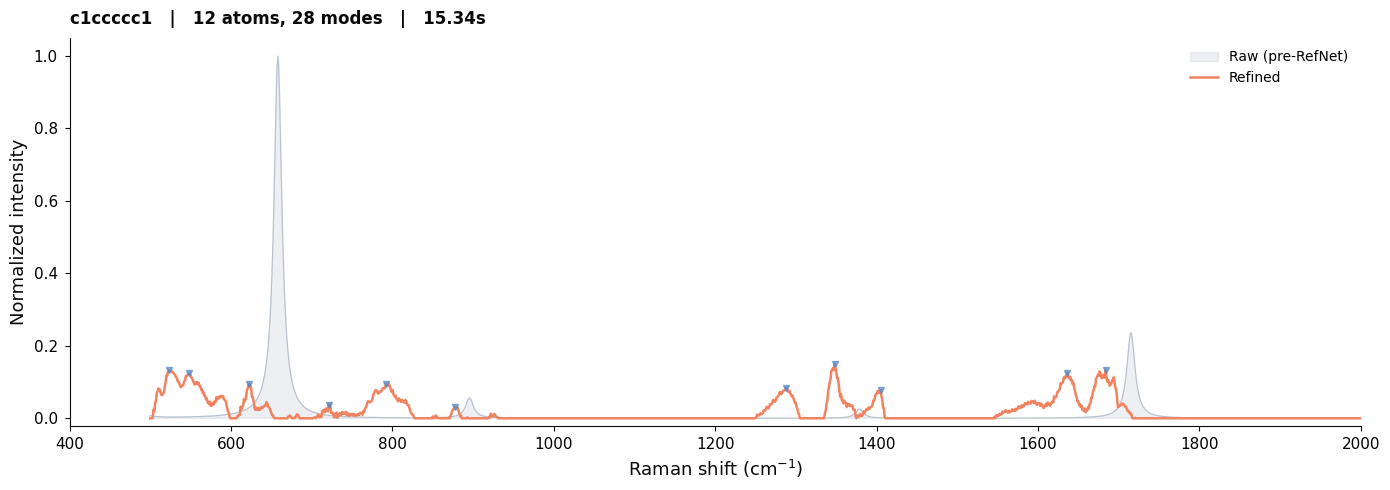

In [5]:
fig, ax = plot_spectrum(result)
plt.show()

In [6]:
peak_table(result)

  #   Position (cm-1)   Intensity
----------------------------------
  1            1348.0      0.1494
  2            1684.0      0.1331
  3             523.0      0.1321
  4            1636.0      0.1253
  5             548.0      0.1241
  6             792.0      0.0947
  7             622.0      0.0944
  8            1288.0      0.0844
  9            1405.0      0.0780
 10             722.0      0.0380
 11             878.0      0.0315


## Batch prediction

In [7]:
# --- Batch: overlay multiple molecules ---
molecules = {
    'Benzene': 'c1ccccc1',
    'Ethanol': 'CCO',
    'Aspirin': 'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine': 'Cn1c(=O)c2c(ncn2C)n(C)c1=O',
}

predictor = RamanPredictor()
results = {}
for name, smi in molecules.items():
    print(f"Predicting {name} ({smi})...")
    results[name] = predictor.predict.remote(smi)
    print(f"  -> {results[name]['n_atoms']} atoms, {results[name]['timing']['total_s']:.2f}s")

Predicting Benzene (c1ccccc1)...
  -> 12 atoms, 5.17s
Predicting Ethanol (CCO)...
  -> 9 atoms, 10.19s
Predicting Aspirin (CC(=O)Oc1ccccc1C(=O)O)...
  -> 21 atoms, 9.53s
Predicting Caffeine (Cn1c(=O)c2c(ncn2C)n(C)c1=O)...
  -> 24 atoms, 3.15s


In [ ]:
# --- Overlay plot ---
colors = [AMBER, AEGEAN, SEAWEED, '#B5699B']
fig, ax = plt.subplots(1, 1, figsize=(14, 6), facecolor='white')

for i, (name, res) in enumerate(results.items()):
    x = np.array(res['x_grid'])
    y = np.array(res['spectrum_refined'])
    ax.plot(x, y + i * 0.15, color=colors[i % len(colors)], lw=1.5, label=name)

ax.set_xlabel(r'Raman shift (cm$^{-1}$)', fontsize=13, fontweight='medium', color=A_BLACK)
ax.set_ylabel('Normalized intensity (offset)', fontsize=13, fontweight='medium', color=A_BLACK)
ax.set_title('SpectraLoRA Predictions', fontsize=14, fontweight='semibold', color=A_BLACK, loc='left', pad=10)
ax.set_xlim(400, 2000)
ax.legend(fontsize=11, frameon=False, loc='upper right')
arcadia_style(ax)
fig.tight_layout()
plt.show()

## Predicted vs Experimental — Ground Truth Comparison

Load measured Raman spectra from the experimental database, predict via the endpoint, and overlay.

In [ ]:
import pandas as pd
import ast
import sqlite3
import json
import zlib

# Load experimental spectra
REPO_ROOT = ".."
spec_df = pd.read_csv(f"{REPO_ROOT}/ramanchembl_pipeline/experimental_data/raman_spectra_db.csv")

# --- 9 experimental molecules (picked by best coverage@10 from stats_v2) ---
MOLECULES = {
    "L-Arginine":           {"smiles": "N[C@@H](CCCNC(=N)N)C(=O)O",                          "exp_id": 32},   # cov=0.571
    "Citric Acid":          {"smiles": "OC(=O)CC(O)(CC(=O)O)C(=O)O",                          "exp_id": 14},   # cov=0.474
    "Estrone":              {"smiles": "C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc43)[C@@H]1CCC2=O",  "exp_id": 201},  # cov=0.444
    "Adenine":              {"smiles": "c1nc(N)c2nc[nH]c2n1",                                  "exp_id": 8},    # cov=0.400
    "L-Tryptophan":         {"smiles": "N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O",                    "exp_id": 38},   # cov=0.400
    "N-Acetyl-Glucosamine": {"smiles": "CC(=O)N[C@@H]1[C@@H](O)[C@H](O)[C@@H](CO)OC1O",      "exp_id": 45},   # cov=0.400
    "Glutathione":          {"smiles": "N[C@@H](CCC(=O)N[C@@H](CS)C(=O)NCC(=O)O)C(=O)O",     "exp_id": 27},   # cov=0.393
    "L-Histidine":          {"smiles": "N[C@@H](Cc1c[nH]cn1)C(=O)O",                          "exp_id": 34},   # cov=0.385
    "Diethylstilbestrol":   {"smiles": "CC(/C=C(/CC)c1ccc(O)cc1)c1ccc(O)cc1",                  "exp_id": 198},  # cov=0.368
}

# --- 9 amide/peptide molecules from RamanChemBL (best DFT fingerprint coverage@10 in eval set) ---
PEPTIDES = {
    "CHEMBL2281776 (51at)":  {"smiles": "C[C@H](c1ccc(c(c1)F)c1ccccc1)C(=O)NN1C(=O)CS[C@H]1c1c(F)cccc1F",                         "db_id": 126849},  # cov=0.571
    "CHEMBL1383658 (57at)":  {"smiles": "CCOc1ccc(cc1)n1cc(C(=O)NCc2ccco2)c2c(c1=O)cc(c(c2)OC)OC",                                  "db_id": 30124},   # cov=0.550
    "CHEMBL115326 (68at)":   {"smiles": "ONC(=O)[C@H]([C@H](C(=O)N[C@H](C(=O)N)Cc1ccccc1)CC(C)C)CSCC(=O)c1ccccc1",                 "db_id": 5643},    # cov=0.545
    "CHEMBL1543951 (41at)":  {"smiles": "COCCN(c1ccccc1C)C(=O)Nc1ccccc1",                                                            "db_id": 56512},   # cov=0.542
    "CHEMBL2028866 (68at)":  {"smiles": "NCCCC[C@@H](C(=O)NCCC(=O)N[C@H](C(=O)O)Cc1c[nH]cn1)NC(=O)NS(=O)(=O)c1ccc(cc1)F",          "db_id": 109465},  # cov=0.536
    "CHEMBL1253917 (54at)":  {"smiles": "COCc1cc2c(n1C)c(ncn2)Oc1ccc(c(c1)Cl)NC(=O)Nc1cccc(c1)C(F)(F)F",                            "db_id": 13661},   # cov=0.500
    "CHEMBL1985581 (53at)":  {"smiles": "O=C(C(=O)Nc1cc(ccc1C)N(=O)=O)Cc1nc2ccc(cc2nc1O)C(=O)c1ccccc1",                             "db_id": 104207},  # cov=0.474
    "CHEMBL1289664 (51at)":  {"smiles": "CC[C@](C(F)(F)F)(c1nnn(c1)Cc1ccc2c(c1)sc(c2c1ccc(cc1)F)C(=O)N)O",                          "db_id": 16048},   # cov=0.474
    "CHEMBL2028863 (67at)":  {"smiles": "O=C(NS(=O)(=O)c1ccc(cc1)F)N[C@H](C(=O)NCCC(=O)N[C@H](C(=O)O)Cc1c[nH]cn1)Cc1ccccc1",      "db_id": 109464},  # cov=0.458
}

def load_experimental_spectrum(exp_id):
    """Load and normalize an experimental spectrum from the DB."""
    row = spec_df[spec_df["id"] == exp_id].iloc[0]
    wn = np.array(ast.literal_eval(row["wavenumbers"]), dtype=np.float64)
    intensity = np.array(ast.literal_eval(row["intensity"]), dtype=np.float64)
    intensity = np.clip(intensity, 0, None)
    intensity = intensity / (intensity.max() + 1e-12)
    return wn, intensity

def load_dft_spectrum(db_id, sigma=12.0, scale=0.967):
    """Load DFT freq + Raman activity from molecule.db and broaden into a spectrum."""
    con = sqlite3.connect(f"{REPO_ROOT}/ramanchembl_pipeline/dataset/molecule.db")
    cur = con.cursor()
    cur.execute("SELECT blob_data FROM molecule WHERE id = ?", (db_id,))
    row = cur.fetchone()
    con.close()
    payload = json.loads(zlib.decompress(row[0]))
    freq = np.array(payload["freq"], dtype=np.float64) * scale
    activity = np.array(payload["Raman Activ"], dtype=np.float64)
    valid = (freq > 1e-8) & np.isfinite(freq) & np.isfinite(activity)
    freq, activity = freq[valid], activity[valid]
    # Lorentzian broadening onto standard grid
    x_grid = np.linspace(500, 4000, 3501)
    lx = freq[:, None] - x_grid[None, :]
    ly = (sigma / (2 * np.pi)) / (lx**2 + 0.25 * sigma**2)
    spectrum = np.sum(activity[:, None] * ly, axis=0)
    spectrum = np.clip(spectrum, 0, None)
    spectrum = spectrum / (spectrum.max() + 1e-12)
    return x_grid, spectrum

print(f"Loaded {len(spec_df)} experimental spectra")
print(f"Experimental: {len(MOLECULES)} molecules (best coverage@10: 0.37-0.57)")
print(f"DFT peptides: {len(PEPTIDES)} molecules (best DFT coverage@10: 0.46-0.57)")

In [ ]:
# --- Run predictions for experimental molecules + peptides ---
predictor = RamanPredictor()

print("=== Experimental molecules ===")
predictions = {}
for name, info in MOLECULES.items():
    print(f"  {name}...", end=" ")
    pred = predictor.predict.remote(info["smiles"])
    predictions[name] = pred
    print(f"{pred['n_atoms']} atoms, {pred['timing']['total_s']:.1f}s")

print(f"\n=== Peptides ===")
peptide_preds = {}
for name, info in PEPTIDES.items():
    print(f"  {name}...", end=" ")
    pred = predictor.predict.remote(info["smiles"])
    peptide_preds[name] = pred
    print(f"{pred['n_atoms']} atoms, {pred['timing']['total_s']:.1f}s")

print(f"\nDone: {len(predictions)} experimental + {len(peptide_preds)} peptides")

In [ ]:
# --- Separate overlay plot for each molecule: Predicted vs Experimental ---
from scipy.signal import find_peaks

for name, info in MOLECULES.items():
    pred = predictions[name]
    exp_wn, exp_int = load_experimental_spectrum(info["exp_id"])

    x_pred = np.array(pred["x_grid"])
    y_pred = np.array(pred["spectrum_refined"])
    y_raw = np.array(pred["spectrum_raw"])

    # Determine shared x range
    xlo = max(400, exp_wn.min() - 50)
    xhi = min(2000, exp_wn.max() + 50)

    # Cosine similarity in the overlap region
    exp_interp = np.interp(x_pred, exp_wn, exp_int, left=0, right=0)
    mask = (x_pred >= xlo) & (x_pred <= xhi)
    dot = np.dot(y_pred[mask], exp_interp[mask])
    cos_sim = dot / (np.linalg.norm(y_pred[mask]) * np.linalg.norm(exp_interp[mask]) + 1e-12)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4.5), facecolor="white")

    # Experimental
    ax.plot(exp_wn, exp_int, color=A_BLACK, lw=1.8, label="Experimental", zorder=3)

    # Predicted refined
    ax.plot(x_pred, y_pred, color=AMBER, lw=1.6, label="Predicted (refined)", zorder=2)

    # Predicted raw as faint fill
    ax.fill_between(x_pred, y_raw, alpha=0.1, color=MARINE)

    ax.set_xlim(xlo, xhi)
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel(r"Raman shift (cm$^{-1}$)", fontsize=13, fontweight="medium", color=A_BLACK)
    ax.set_ylabel("Normalized intensity", fontsize=13, fontweight="medium", color=A_BLACK)
    ax.set_title(
        f"{name}   |   {pred['n_atoms']} atoms   |   cos={cos_sim:.3f}   |   {pred['timing']['total_s']:.1f}s",
        fontsize=12, fontweight="semibold", color=A_BLACK, loc="left", pad=10,
    )
    ax.legend(fontsize=10, frameon=False, loc="upper right")
    arcadia_style(ax)
    fig.tight_layout()
    plt.show()

## Predicted vs DFT — Peptides from RamanChemBL

Di- and tripeptides from `molecule.db`. DFT reference (black) from B3LYP/TZVP Gaussian calculations stored in the database, predicted (amber) from the inference endpoint.

In [ ]:
# --- Separate overlay plot for each peptide: Predicted vs DFT reference ---
for name, info in PEPTIDES.items():
    pred = peptide_preds[name]
    dft_x, dft_y = load_dft_spectrum(info["db_id"])

    x_pred = np.array(pred["x_grid"])
    y_pred = np.array(pred["spectrum_refined"])
    y_raw = np.array(pred["spectrum_raw"])

    # Cosine similarity over fingerprint region
    mask = (x_pred >= 500) & (x_pred <= 2000)
    dot = np.dot(y_pred[mask], dft_y[mask])
    cos_sim = dot / (np.linalg.norm(y_pred[mask]) * np.linalg.norm(dft_y[mask]) + 1e-12)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4.5), facecolor="white")

    # DFT reference
    ax.plot(dft_x, dft_y, color=A_BLACK, lw=1.8, label="DFT (B3LYP/TZVP)", zorder=3)

    # Predicted refined
    ax.plot(x_pred, y_pred, color=AMBER, lw=1.6, label="Predicted (refined)", zorder=2)

    # Predicted raw as faint fill
    ax.fill_between(x_pred, y_raw, alpha=0.1, color=MARINE)

    ax.set_xlim(400, 2000)
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel(r"Raman shift (cm$^{-1}$)", fontsize=13, fontweight="medium", color=A_BLACK)
    ax.set_ylabel("Normalized intensity", fontsize=13, fontweight="medium", color=A_BLACK)
    ax.set_title(
        f"{name}   |   {pred['n_atoms']} atoms   |   cos={cos_sim:.3f}   |   {pred['timing']['total_s']:.1f}s",
        fontsize=12, fontweight="semibold", color=A_BLACK, loc="left", pad=10,
    )
    ax.legend(fontsize=10, frameon=False, loc="upper right")
    arcadia_style(ax)
    fig.tight_layout()
    plt.show()